<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/temp/GET_FII_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
!pip install pyotp --q
!pip install smartapi-python==1.4.1 --q
!pip install logzero --q

In [105]:
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator,YearLocator

In [106]:
# package import statement
from SmartApi import SmartConnect #or from SmartApi.smartConnect import SmartConnect
import pyotp
from logzero import logger
import time
import os
import urllib
import json
import pandas as pd
import datetime as dt

api_key = 'xOHnB7MG'
username = 'M55123447'
pwd = '1471'
smartApi = SmartConnect(api_key)
try:
    token = "GJZACUQI2TTAIBHBA34XNFJURQ"
    totp = pyotp.TOTP(token).now()
except Exception as e:
    logger.error("Invalid Token: The provided token is not valid.")
    raise e

correlation_id = "abcde"
data = smartApi.generateSession(username, pwd, totp)

if data['status'] == False:
    logger.error(data)

else:
    # login api call
    # logger.info(f"You Credentials: {data}")
    authToken = data['data']['jwtToken']
    refreshToken = data['data']['refreshToken']
    # fetch the feedtoken
    feedToken = smartApi.getfeedToken()
    # fetch User Profile
    res = smartApi.getProfile(refreshToken)
    smartApi.generateToken(refreshToken)
    res=res['data']['exchanges']
#Download Nifty50 Index Data
params = {
           "exchange": "NSE",
           "symboltoken": '99926000',
           "interval": "ONE_DAY",
           "fromdate": (dt.datetime(2020, 9, 21).strftime('%Y-%m-%d %H:%M')),
           "todate": (dt.datetime.today().strftime('%Y-%m-%d %H:%M'))
         }
nifty_data = smartApi.getCandleData(params)
nifty_data_format= pd.DataFrame(nifty_data["data"],
                               columns = ["Date","Open","High","Low","Close","Volume"])
nifty_data_format.set_index("Date",inplace=True)
nifty_data_format.index = pd.to_datetime(nifty_data_format.index)
nifty_data_format.index = nifty_data_format.index.tz_localize(None)

In [107]:
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.simplefilter(action='ignore', category=Warning)
import yfinance as yf

In [108]:
import numpy as np
import pandas as pd
#from pykalman import KalmanFilter
#import pandas_ta as ta

In [109]:
nif=nifty_data_format

In [110]:
nif.tail(2)

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-12,23674.85,23833.15,23556.30,23639.15,0
2026-03-13,23462.50,23492.40,23305.75,23395.75,0


In [111]:
nif.head(2)
nif.reset_index(inplace=True)

In [112]:
fii=pd.read_csv('https://raw.githubusercontent.com/anirbanghoshsbi/.github.io/refs/heads/master/work/ml/fii_dii_sorted.csv')

In [113]:
# Convert both Date columns to datetime
nif["Date"] = pd.to_datetime(nif["Date"])
fii["Date"] = pd.to_datetime(fii["Date"])

# Remove timestamp part from df2
nif["Date"] = nif["Date"].dt.date
fii["Date"] = fii["Date"].dt.date

In [114]:
fii_fig = pd.merge(fii, nif, on="Date", how="inner")

# Change Here

In [115]:
fii_fig['Cash']=fii_fig.FIICash+fii_fig.DIIcash

In [116]:
fii_fig['Cashfut']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signalfutcash']=fii_fig['Cashfut'].ewm(span=22,adjust=False).mean()
fii_fig['signal10futcash']=fii_fig['Cashfut'].ewm(span=10,adjust=False).mean()

# Plot FII minus DII

In [117]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=25,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=10,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [118]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=100, adjust=False).mean()-fii_fig['Cash'].ewm(span=250, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=45,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=20,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [119]:
fii_fig['macd']=fii_fig['DIIcash'].ewm(span=50, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=35,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']

In [120]:
fii_fig['macdx']=fii_fig['FIICash'].ewm(span=50, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signalx']=fii_fig['macdx'].ewm(span=35,adjust=False).mean()
fii_fig['signal10x']=fii_fig['macdx'].ewm(span=10,adjust=False).mean()
fii_fig['histx']=fii_fig['macdx']-fii_fig['signalx']

# Plot FII , DII , Difference comparison

In [121]:
fii_fig['macd']=fii_fig['FIICash'].ewm(span=20, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']


In [122]:
fii_fig['macd_dom']=fii_fig['DIIcash'].ewm(span=20, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal_dom']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['signal_dom_10']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['hist_dom']=fii_fig['macd_dom']-fii_fig['signal_dom']

In [123]:
nif.reset_index(inplace=True)
fii_fig.reset_index(inplace=True)
# Convert the 'Date' column in both DataFrames to the same data type
nif['Date'] = pd.to_datetime(nif['Date'])
fii_fig['Date'] = pd.to_datetime(fii_fig['Date'])

# Merge nif and fii_fig DataFrames on the 'Date' column
merged_df = pd.merge(nif, fii_fig, on='Date')


In [124]:
fii_fig['MA200']=fii_fig.Close.rolling(window=200).mean()
fii_fig['MA20']=fii_fig.Close.rolling(window=20).mean()

In [125]:
fii_fig.columns

Index(['index', 'Date', 'FIICash', 'DIIcash', 'Open', 'High', 'Low', 'Close',
       'Volume', 'Cash', 'Cashfut', 'signalfutcash', 'signal10futcash',
       'macdy', 'signaly', 'signal10y', 'histy', 'macd', 'signal', 'signal10',
       'hist', 'macdx', 'signalx', 'signal10x', 'histx', 'macd_dom',
       'signal_dom', 'signal_dom_10', 'hist_dom', 'MA200', 'MA20'],
      dtype='object')

# Plot Smart Money (FII)

In [126]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd'], mode='lines', name = 'macd'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=df.Date, y=df['signal'], mode='lines', name = 'signal'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date, y=df['signal10'], mode='lines', name = 'signal10'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="Smart Money And Nifty")

fig.show()

In [127]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
#nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money DII","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd_dom'], mode='lines', name = 'macd'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date,y=df['macd_dom'].rolling(window=10).mean(),mode='lines',name='moving-average 10'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="DII Money And Nifty")

fig.show()

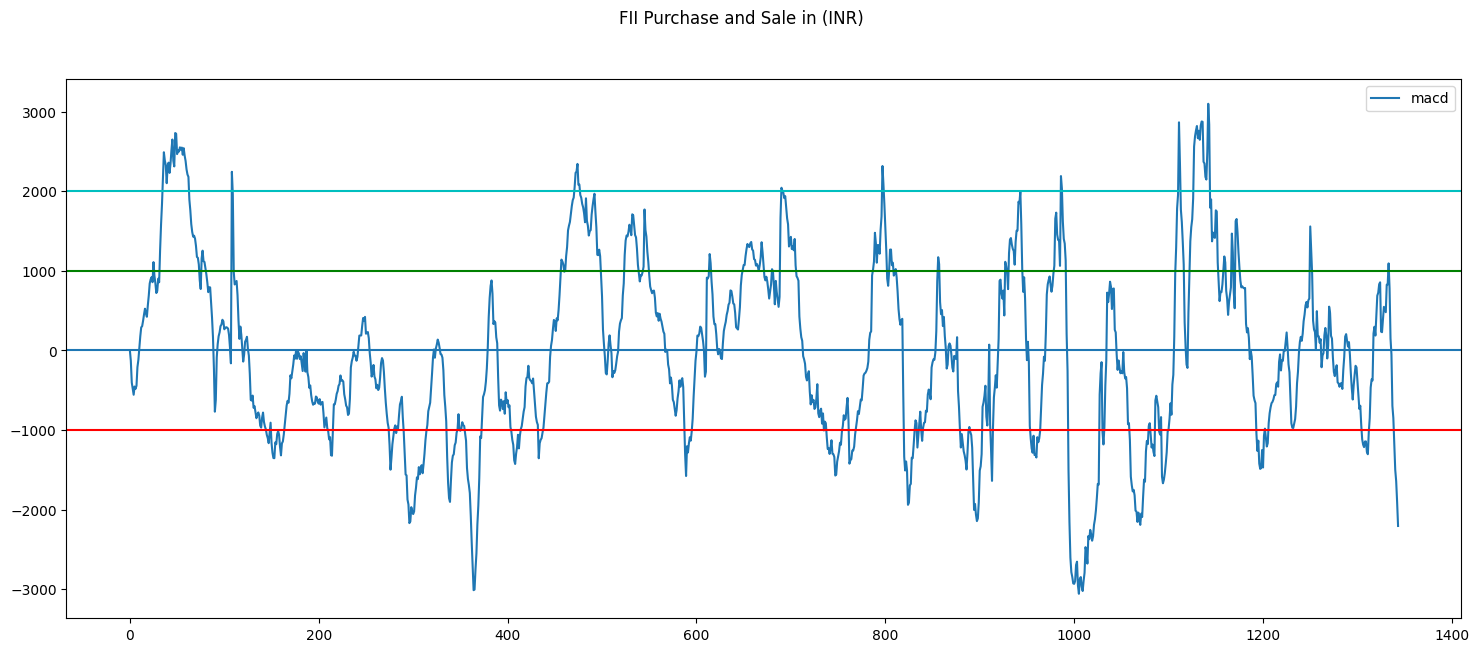

In [128]:
fii_fig['macd'].plot(figsize=(18,7))
plt.axhline(y=0)
plt.axhline(y=1000,color='g')
plt.axhline(y=2000,color='c')
plt.axhline(y=-1000,color='r')
plt.suptitle('FII Purchase and Sale in (INR)')
plt.legend()
plt.show()

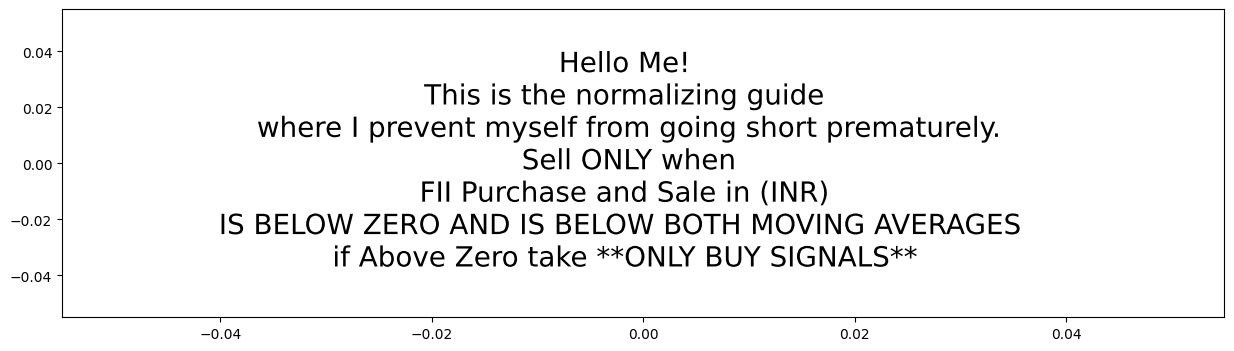

In [129]:
import matplotlib.patheffects as path_effects

fig = plt.figure(figsize=(15, 4))
text = fig.text(0.5, 0.5, 'Hello Me!\n This is the normalizing guide '
                          '\n where I prevent myself from going short prematurely.\n Sell ONLY when'
                           '\nFII Purchase and Sale in (INR)\n'
                           'IS BELOW ZERO AND IS BELOW BOTH MOVING AVERAGES \n'
                           'if Above Zero take **ONLY BUY SIGNALS**',
                ha='center', va='center', size=20)
plt.plot(path_effects=[path_effects.Normal(),path_effects.Normal()])
text.set_path_effects([path_effects.Normal()])


In [130]:
fii_fig['macd_z'] = (
    fii_fig['macd'] - fii_fig['macd'].rolling(252).mean()
) / fii_fig['macd'].rolling(252).std()

In [131]:
fii_fig['macd_regime'] = pd.cut(
    fii_fig['macd_z'],
    bins=[-np.inf,-1,-0.5,0,0.5,1,np.inf],
    labels=[
        'panic_selling',
        'strong_selling',
        'weak_selling',
        'weak_buying',
        'strong_buying',
        'euphoria'
    ]
)

In [175]:
fii_fig['ret_10d'] = (fii_fig['Close'].shift(-5) / fii_fig['Close'] - 1)*100

fii_fig.groupby('macd_regime')['ret_10d'].mean()

,ret_10d
macd_regime,
panic_selling,0.281048
strong_selling,0.179607
weak_selling,0.081410
weak_buying,0.133621
strong_buying,-0.036363
euphoria,0.243827


In [176]:
#fii_fig["Date"] = pd.to_datetime(fii_fig["Date"])

regime_slice = (
    fii_fig
    .set_index("Date")
    .loc["2025-04-03":"2025-04-27", ["macd_regime","ret_10d"]]
)

In [177]:
regime_slice

,macd_regime,ret_10d
Date,,
2025-04-03,euphoria,-1.813110
2025-04-04,euphoria,1.851605
2025-04-07,strong_buying,5.755902
2025-04-08,weak_buying,5.838697
2025-04-09,weak_buying,7.707435
2025-04-11,weak_buying,5.864148
2025-04-15,strong_buying,4.288308
2025-04-16,euphoria,3.453911
2025-04-17,euphoria,0.786948


In [147]:
fii_fig['macd_regime'].iloc[-1]

'panic_selling'

In [148]:
fii_fig.groupby('macd_regime')['ret_10d'].median()*100

,ret_10d
macd_regime,
panic_selling,-0.013008
strong_selling,0.017299
weak_selling,-0.075441
weak_buying,0.073821
strong_buying,0.148016
euphoria,0.051368


In [149]:
fii_fig['trend_regime'] = np.where(
    fii_fig['Close'] > fii_fig['MA20'],
    'above_MA20',
    'below_MA20'
)

In [153]:
pd.pivot_table(
    fii_fig,
    values='ret_10d',
    index='macd_regime',
    columns='trend_regime',
    aggfunc='mean'
)

trend_regime,above_MA20,below_MA20
macd_regime,,
panic_selling,0.000415,0.000348
strong_selling,0.000688,0.000988
weak_selling,0.000138,-0.001294
weak_buying,0.000366,-0.000551
strong_buying,0.000573,-0.000383
euphoria,0.000703,0.003134


In [151]:
{
  "signal_name": "FII_MACD_Regime_Forward_Return",
  "horizon_days": 10,
  "description": "10-day forward Nifty return conditioned on FII MACD regime and trend regime relative to MA50.",
  "trend_variable": "Close_vs_MA50",
  "regimes": {
    "panic_selling": {
      "above_MA50": -0.0002540772,
      "below_MA50": 0.0106831230,
      "interpretation": "Oversold bounce in bear markets."
    },
    "strong_selling": {
      "above_MA50": 0.0026565867,
      "below_MA50": 0.0023052036,
      "interpretation": "Mild positive drift after selling."
    },
    "weak_selling": {
      "above_MA50": 0.0041618008,
      "below_MA50": 0.0066419390,
      "interpretation": "Stabilization bounce."
    },
    "weak_buying": {
      "above_MA50": 0.0034906377,
      "below_MA50": -0.0012507730,
      "interpretation": "Neutral in bull market, weak in bear market."
    },
    "strong_buying": {
      "above_MA50": -0.0011718995,
      "below_MA50": -0.0295404106,
      "interpretation": "Failed rally signal, especially in bear markets."
    },
    "euphoria": {
      "above_MA50": 0.0060588610,
      "below_MA50": 0.0433108930,
      "interpretation": "Momentum continuation or short squeeze."
    }
  },
  "agent_guidance": {
    "bull_market_strategy": {
      "condition": "Close > MA50",
      "preferred_regimes": ["weak_selling", "weak_buying", "euphoria"]
    },
    "bear_market_strategy": {
      "condition": "Close < MA50",
      "preferred_regimes": ["panic_selling", "weak_selling", "euphoria"]
    },
    "avoid_long": [
      "strong_buying"
    ]
  }
}

{'signal_name': 'FII_MACD_Regime_Forward_Return',
 'horizon_days': 10,
 'description': '10-day forward Nifty return conditioned on FII MACD regime and trend regime relative to MA50.',
 'trend_variable': 'Close_vs_MA50',
 'regimes': {'panic_selling': {'above_MA50': -0.0002540772,
   'below_MA50': 0.010683123,
   'interpretation': 'Oversold bounce in bear markets.'},
  'strong_selling': {'above_MA50': 0.0026565867,
   'below_MA50': 0.0023052036,
   'interpretation': 'Mild positive drift after selling.'},
  'weak_selling': {'above_MA50': 0.0041618008,
   'below_MA50': 0.006641939,
   'interpretation': 'Stabilization bounce.'},
  'weak_buying': {'above_MA50': 0.0034906377,
   'below_MA50': -0.001250773,
   'interpretation': 'Neutral in bull market, weak in bear market.'},
  'strong_buying': {'above_MA50': -0.0011718995,
   'below_MA50': -0.0295404106,
   'interpretation': 'Failed rally signal, especially in bear markets.'},
  'euphoria': {'above_MA50': 0.006058861,
   'below_MA50': 0.04331

In [152]:
{
  "signal_name": "FII_MACD_Regime_Forward_Return",
  "horizon_days": 5,
  "description": "5-day forward Nifty return conditioned on FII MACD regime and trend regime relative to MA20.",
  "trend_variable": "Close_vs_MA20",
  "regimes": {
    "panic_selling": {
      "above_MA20": -0.0024585336,
      "below_MA20": 0.0093548542,
      "interpretation": "Capitulation selling often leads to a strong mean-reversion bounce when the market is already below trend."
    },
    "strong_selling": {
      "above_MA20": 0.0059188999,
      "below_MA20": 0.0006126134,
      "interpretation": "Heavy selling pressure tends to stabilize with mild positive drift, especially when the market remains above trend."
    },
    "weak_selling": {
      "above_MA20": 0.0040891869,
      "below_MA20": 0.0067676796,
      "interpretation": "Profit-taking phase with continued positive drift, often representing healthy pullbacks in trends."
    },
    "weak_buying": {
      "above_MA20": 0.0032938272,
      "below_MA20": -0.0011244001,
      "interpretation": "Small buying pressure supports continuation in uptrends but fails to reverse weak markets."
    },
    "strong_buying": {
      "above_MA20": -0.0050666287,
      "below_MA20": -0.0082905069,
      "interpretation": "Aggressive buying often occurs near exhaustion points and may precede short-term pullbacks."
    },
    "euphoria": {
      "above_MA20": 0.0070438067,
      "below_MA20": 0.0098813739,
      "interpretation": "Momentum phase where liquidity expansion leads to strong continuation or squeeze moves."
    }
  },
  "agent_guidance": {
    "bull_market_strategy": {
      "condition": "Close > MA20",
      "preferred_regimes": ["weak_selling", "weak_buying", "euphoria"]
    },
    "bear_market_strategy": {
      "condition": "Close < MA20",
      "preferred_regimes": ["panic_selling", "weak_selling", "euphoria"]
    },
    "avoid_long": [
      "strong_buying"
    ]
  }
}

{'signal_name': 'FII_MACD_Regime_Forward_Return',
 'horizon_days': 5,
 'description': '5-day forward Nifty return conditioned on FII MACD regime and trend regime relative to MA20.',
 'trend_variable': 'Close_vs_MA20',
 'regimes': {'panic_selling': {'above_MA20': -0.0024585336,
   'below_MA20': 0.0093548542,
   'interpretation': 'Capitulation selling often leads to a strong mean-reversion bounce when the market is already below trend.'},
  'strong_selling': {'above_MA20': 0.0059188999,
   'below_MA20': 0.0006126134,
   'interpretation': 'Heavy selling pressure tends to stabilize with mild positive drift, especially when the market remains above trend.'},
  'weak_selling': {'above_MA20': 0.0040891869,
   'below_MA20': 0.0067676796,
   'interpretation': 'Profit-taking phase with continued positive drift, often representing healthy pullbacks in trends.'},
  'weak_buying': {'above_MA20': 0.0032938272,
   'below_MA20': -0.0011244001,
   'interpretation': 'Small buying pressure supports conti